# Analysis of Different K Values
After playing around with generating quotes, I got curious about how many unique answers could be generated given different k values. It seemed like even for k values that were relatively low, such as 2 or 3, the phrases generated were merely direct quotes rather than being uniquely generated.

## Corpora
I used three different corpora for my testing. The first is just the list of inspirational quotes given in the exercise. The second is the King James Version of the Bible in its entirety because I realized I had it in txt on my computer from a different project a while back. For the third, I was curious how the relative coherentness compared across languages since I speak Spanish, so I included the Reina Valera Bible because it is a large Spanish work in public domain (I thought about Don Quijote, but the Spanish is so archaic it would be hard to tell how distorted it was by the generation). What I downloaded from project Gutenburg turned out to not have the entire text, but it has enough for my purposes, and that gives three different sizes to compare.


In [26]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot

## Results from Testing
Since building the dictionaries takes some time for the larger works and since the texts are not included in git, I decided the easiest way to present the results would be to save them in a csv that is included, then they can be analyzed in a notebook.

The results for each combination of text and k value show the number of windows/dictionary entries that have a given number of options, ending with 5 or more.

In [14]:
df_results = pd.read_csv('fun_results.csv', index_col=[0])
df_results.head()

,text,k,size,1_opt,2_opt,3_opt,4_opt,5+_opt
0,quotes,1,794,497,121,60,27,89
1,quotes,2,2222,1887,210,50,22,53
2,quotes,3,2770,2614,117,22,4,13
3,quotes,4,2922,2836,78,5,0,3
4,quotes,5,2979,2926,52,0,0,1


## Visual Comparison
We can then compare the number of windows with each number of options in a bar chart to visualize how the number of options per window are distributed.

To clean the data up in preparation for this, we can change it from a wide format to a long format so that we can more easily access the data from the different numbers of options. 

In [21]:
# Melt the options into separate rows
df_long = df_results.melt(id_vars=['text', 'k', 'size'], 
        var_name='num_opts', value_name='windows_w_opts')

df_long.head()

,text,k,size,num_opts,windows_w_opts
0,quotes,1,794,1_opt,497
1,quotes,2,2222,1_opt,1887
2,quotes,3,2770,1_opt,2614
3,quotes,4,2922,1_opt,2836
4,quotes,5,2979,1_opt,2926


Then we can add a column for the percentage of windows with that number of options to make it easier to compare across the different sized data sets.

In [22]:
df_long['windows_percent'] = 100 * df_long['windows_w_opts'] / df_long['size']

df_long.head()

,text,k,size,num_opts,windows_w_opts,windows_percent
0,quotes,1,794,1_opt,497,62.594458
1,quotes,2,2222,1_opt,1887,84.923492
2,quotes,3,2770,1_opt,2614,94.368231
3,quotes,4,2922,1_opt,2836,97.056810
4,quotes,5,2979,1_opt,2926,98.220879


### Inspirational Quotes Results
Rather than cramming everything into one chart, we can look at the data from each corpus individually. Here is how the percentage of windows with different amounts of possible next word options compares for different k values using the inspirational quotes corpus.

[Text(0.5, 1.0, 'Quotes Results'),
 Text(0.5, 0, 'Number of options per window'),
 Text(0, 0.5, 'Percent of total windows')]

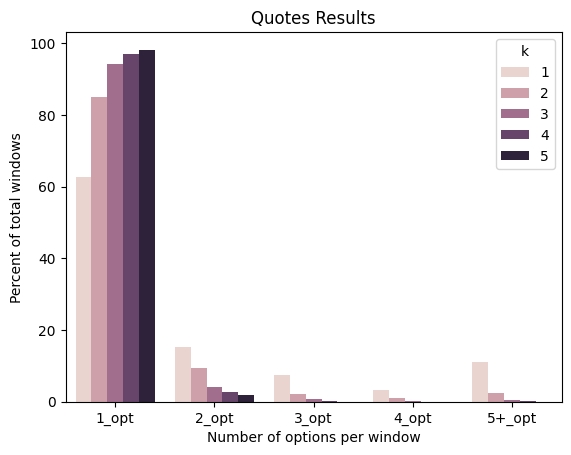

In [34]:
quotes_filter = df_long['text'] == 'quotes'
plot1 = sns.barplot(data=df_long[quotes_filter], hue='k', x='num_opts', y='windows_percent', errorbar=None)

# Add labels for looks
plot1.set(
    title='Quotes Results',
    xlabel='Number of options per window',
    ylabel='Percent of total windows'
)

Here we can see that even by k = 3, there are hardly any windows with more than 1 options for picking the next word.

### KJV Results
Here we can see that for a significantly larger corpus, at k = 1 there is a much larger percentage of windows with 5 or more options. However, by k = 5 it is nearly just as bad as for the inspirational quotes corpus.

[Text(0.5, 1.0, 'KJV Results'),
 Text(0.5, 0, 'Number of options per window'),
 Text(0, 0.5, 'Percent of total windows')]

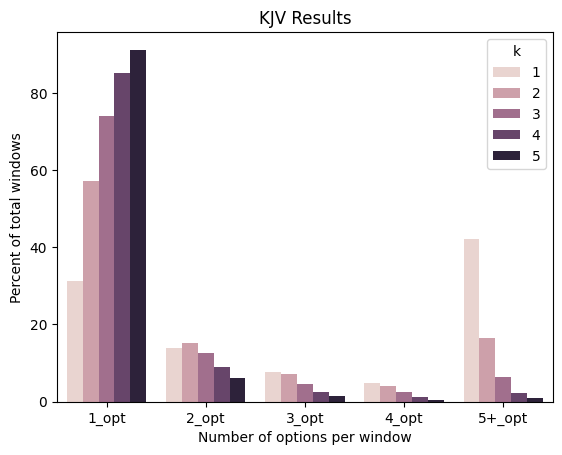

In [35]:
kjv_filter = df_long['text'] == 'kjv'
plot2 = sns.barplot(data=df_long[kjv_filter], hue='k', x='num_opts', y='windows_percent', errorbar=None)

# Add labels for looks
plot2.set(
    title='KJV Results',
    xlabel='Number of options per window',
    ylabel='Percent of total windows'
)

### Reina Valera Results
For the Reina Valera that falls between the two in terms of corpus size, we see a result that is roughly between the two previous results -- not quite as bad as with the quotes, but not quite as good as with the KJV. The difference in language and grammatical structure also does not seem to affect the results much, at least compared at this scale.

[Text(0.5, 1.0, 'RV Results'),
 Text(0.5, 0, 'Number of options per window'),
 Text(0, 0.5, 'Percent of total windows')]

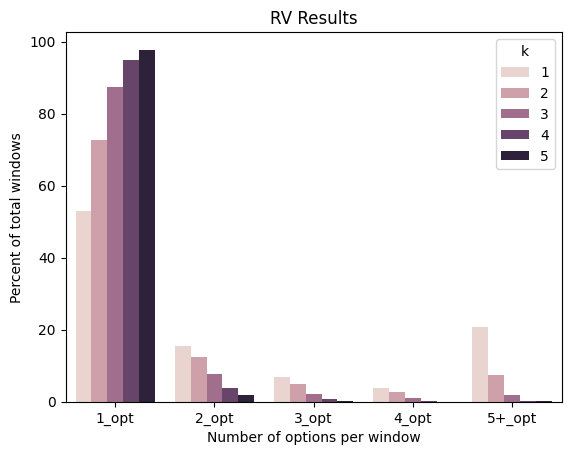

In [36]:
rv_filter = df_long['text'] == 'rv'
plot3 = sns.barplot(data=df_long[rv_filter], hue='k', x='num_opts', y='windows_percent', errorbar=None)

# Add labels for looks
plot3.set(
    title='RV Results',
    xlabel='Number of options per window',
    ylabel='Percent of total windows'
)

## Originality of the Generator for Different Values of k
With this style of generation, there is a very heavy trade-off between the coherence of the generated phrases and the originality of the phrases. As k increases, the grammar very quickly becomes more coherent, but at the same time, it begins to merely quote the original corpus rather than give a unique output.

Given the percent of windows with a given number of options, and assuming we are picking randomly from those options, we can actually estimate the probability that we get a completely original phrase of a given length. If we say the percentage of windows with i options is $p_i$, then the probability of getting an exact quote of length $n$ should be: 
$$p=[\sum_{i=1}^{\infty} p_i/i]^n$$
and $1-p$ will give us the probability of a unique quote. We can simplify our estimate by lumping everything with 5 or more options together, as it is in our data, then we can calculate an estimate. 

Since the data was gathered with repeats allowed in the generator, the probability of being unique is technically not excluding the possibility of having the same words come after one another, just that it is not from the same original quote. For example, it's possible that we might have "there is a". However, the probability of being unique will not exclude all cases of picking "there is a", just the one case where they are pulled from the same original sentence. This is less clear with a short phrase, but within a longer a phrase it is okay to have common phrases like "there is a" as long as they are not directly choosing from the same original quote. This could be seen as a limitation of this way of estimating the probability, however, I think we have to allow for this because language uses repetitive structures. 

In [82]:
def prob_unique(text, k, n):
    p = 0
    #     # Add this term to the percent
    #     p += wp / i
    windows_percents = df_long.loc[(df_long['text'] == text) & (df_long['k'] == k)]['windows_percent']

    for i in range(len(windows_percents)):
        # Add the term to the total probability
        p += (windows_percents.iloc[i] / 100) / (i + 1)

    print(p)

    return 1 - (p)**n


Now we can build the probabilities of getting unique strings of length 15 from each corpus.

In [88]:
# A new data frame to store the probabilities
df_probs = pd.DataFrame(columns=['text', 'k', 'prob'])

for text in ['quotes', 'kjv', 'rv']:
    for k in range(1,6):
        # I don't know why it's insisting on printing p in the notebook
        p = prob_unique(text, k, 15)

        # Add  this probability to the dataframe
        df_probs.loc[len(df_probs)] = [text, k, p]


df_probs.head()

0.7582493702770781
0.9112361236123612
0.968748495788207
0.9846908510152863
0.9910036925142666
0.5051816494298594
0.7133186650441935
0.8375249540207587
0.91108632144726
0.949452599633858
0.6816878306878308
0.8261653413764738
0.9259385176501238
0.9710569722561277
0.9880167673969613


,text,k,prob
0,quotes,1,0.984254
1,quotes,2,0.751993
2,quotes,3,0.378894
3,quotes,4,0.206588
4,quotes,5,0.126769


### Visualization
Now we can visualize these probabilities to see how unoriginal the generator really is as k increases.

[Text(0.5, 1.0, 'RV Results'),
 Text(0.5, 0, 'Number of options per window'),
 Text(0, 0.5, 'Percent of total windows')]

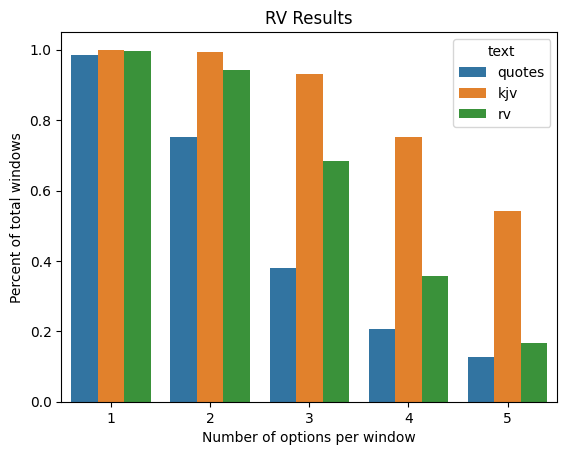

In [89]:
plot4 = sns.barplot(data=df_probs, hue='text', x='k', y='prob', errorbar=None)

# Add labels for looks
plot4.set(
    title='RV Results',
    xlabel='Number of options per window',
    ylabel='Percent of total windows'
)

Here we can see that even for the largest corpus (KJV), at k = 5, nearly half of the time, a 15 word result will be an exact quote from the original. And for the smaller corpora, the results are even worse. For the inspirational quotes, it will return an exact quote over 80% of the time with k = 5. And these results are only for cases where all 15 words are from the exact quote. But there would be many more cases where a significant portion of the generated text is unoriginal even if not every word is the same. So the there is a very large trade-off between coherence and originality.

I think this highlights more than anything else how in language, most of the words we use are common, repetitive words. While the words that add more interest and information are repeated far less. So when one of them gets picked, the probability is already stacked towards following the rest of that specific quote.